# Damage distribution and relative repair — 100 kb / 100 × 1-kb windows

This independent notebook uses the existing 100-kb overlap files to calculate normalized damage with persistence, percent relative repair, simulation-corrected enrichment/persistence, and direct global-count diagnostics.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20,
    'font.size': 10, 'legend.frameon': False,
})

In [3]:
colors = {
    '1m': '#000000', '15m': '#0072B2', '30m': '#E69F00',
    '1h': '#009E73', '4h': '#D55E00', '8h': '#CC79A7',
}


## Analysis structure

Counts are pooled across regions separately for each of the 100 one-kilobase windows spanning −50 to +50 kb. Each timepoint distribution is normalized by its own 100-window total before spatial comparisons. All ATAC, H3K9me3, and H3K27me3 plots share y-limits within each damage type.


In [4]:
from io import StringIO
import subprocess

overlap_base = Path('/cta/users/guneyn23/peak_center_100kb/normal_3states_overtime/overlaps')
output_dir = Path('/cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs')
output_dir.mkdir(parents=True, exist_ok=True)
times = ['1m', '15m', '30m', '1h', '4h', '8h']
regions = ['ATAC', 'H3K9me3', 'H3K27me3']
damages = ['CPD', '64']
kinds = ['real', 'sim']

def overlap_path(region, damage, time, kind):
    return overlap_base / f'{time}_{damage}_{kind}_{region}_100windows_overlap.bed'

def pooled_window_counts(path):
    awk_program = r'''
    BEGIN { OFS="\t" }
    {
        window = ((NR - 1) % 100) + 1
        parts_n = split($4, parts, "_")
        if ((parts[parts_n] + 0) != window) exit 3
        sums[window] += $NF
    }
    END {
        if (NR % 100 != 0) exit 2
        for (window = 1; window <= 100; window++)
            print window, sums[window] + 0
    }
    '''
    completed = subprocess.run(
        ['awk', '-F', '\t', awk_program, str(path)],
        check=True, capture_output=True, text=True,
    )
    return pd.read_csv(StringIO(completed.stdout), sep='\t', header=None, names=['window', 'pooled_count'])

tables = []
for region in regions:
    for damage in damages:
        for kind in kinds:
            for time in times:
                path = overlap_path(region, damage, time, kind)
                if not path.is_file():
                    raise FileNotFoundError(path)
                table = pooled_window_counts(path)
                table.insert(0, 'time', time)
                table.insert(0, 'kind', kind)
                table.insert(0, 'damage', damage)
                table.insert(0, 'region', region)
                table['distance_kb'] = -50 + (table['window'] - 0.5) * 1.0
                table['profile_total_count'] = table['pooled_count'].sum()
                table['damage_percent'] = 100 * table['pooled_count'] / table['profile_total_count']
                tables.append(table)

damage_profiles = pd.concat(tables, ignore_index=True)
damage_profiles.to_csv(output_dir / 'damage_profiles_100kb_1kbwindows.tsv', sep='\t', index=False)
print(f'Written: {output_dir}')
damage_profiles.head()


KeyboardInterrupt: 

In [1]:
# Presentation view: normalized damage distributions above, positive persistence ratios below.
comparison_times = [time for time in times if time != '1m']
persistence_baseline = (
    damage_profiles[damage_profiles['time'] == '1m'][
        ['region', 'damage', 'kind', 'window', 'damage_percent']
    ]
    .rename(columns={'damage_percent': 'damage_percent_1m'})
)
damage_persistence = damage_profiles.merge(
    persistence_baseline,
    on=['region', 'damage', 'kind', 'window'],
    validate='many_to_one',
)
if (damage_persistence['damage_percent_1m'] <= 0).any():
    raise ValueError('At least one 1m window is zero; persistence ratio is undefined.')
damage_persistence['persistence_ratio'] = (
    damage_persistence['damage_percent']
    / damage_persistence['damage_percent_1m']
)

paired_output = output_dir / 'paired_damage_and_persistence'
paired_plot_dir = paired_output / 'plots'
paired_plot_dir.mkdir(parents=True, exist_ok=True)
damage_persistence.to_csv(
    paired_output / 'damage_persistence_100kb_1kbwindows.tsv',
    sep='\t', index=False,
)

# One shared y-axis across all three regions and both CPD/6-4PP groups.
damage_values = damage_persistence['damage_percent']
damage_low, damage_high = damage_values.min(), damage_values.max()
damage_pad = max(0.01, (damage_high - damage_low) * 0.10)
paired_damage_ylim = (max(0, damage_low - damage_pad), damage_high + damage_pad)
persistence_values = damage_persistence.loc[
    damage_persistence['time'].isin(comparison_times), 'persistence_ratio'
]
persistence_pad = max(0.01, (persistence_values.max() - persistence_values.min()) * 0.08)
paired_persistence_ylim = (
    max(0, min(1.0, persistence_values.min()) - persistence_pad),
    max(1.0, persistence_values.max()) + persistence_pad,
)

for region in regions:
    for damage in damages:
        for kind in kinds:
            selected = damage_persistence[
                (damage_persistence['region'] == region)
                & (damage_persistence['damage'] == damage)
                & (damage_persistence['kind'] == kind)
            ]
            baseline = selected[selected['time'] == '1m'].sort_values('window')
            damage_y_min, damage_y_max = paired_damage_ylim
            comparison = selected[selected['time'].isin(comparison_times)]
            persistence_y_min, persistence_y_max = paired_persistence_ylim

            fig, axes = plt.subplots(
                2, len(comparison_times), figsize=(22, 8),
                sharex=True, sharey='row',
            )
            for column_index, time in enumerate(comparison_times):
                current = selected[selected['time'] == time].sort_values('window')
                top_ax = axes[0, column_index]
                bottom_ax = axes[1, column_index]

                top_ax.plot(
                    baseline['distance_kb'], baseline['damage_percent'],
                    color=colors['1m'], label='1m', linewidth=1.8,
                )
                top_ax.plot(
                    current['distance_kb'], current['damage_percent'],
                    color=colors[time], label=time, linewidth=1.8,
                )
                top_ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
                top_ax.set_ylim(damage_y_min, damage_y_max)
                top_ax.set_title(f'1m vs {time}')
                top_ax.legend(frameon=False)
                top_ax.grid(alpha=0.2)

                bottom_ax.plot(
                    current['distance_kb'], current['persistence_ratio'],
                    color=colors[time], linewidth=1.8,
                )
                bottom_ax.axhline(1, color='black', linestyle=':', linewidth=1)
                bottom_ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
                bottom_ax.fill_between(
                    current['distance_kb'], 1, current['persistence_ratio'],
                    where=current['persistence_ratio'].to_numpy() < 1,
                    color='#56B4E9', alpha=0.15, label='Relative depletion',
                )
                bottom_ax.fill_between(
                    current['distance_kb'], 1, current['persistence_ratio'],
                    where=current['persistence_ratio'].to_numpy() > 1,
                    color='#D55E00', alpha=0.15, label='Relative persistence',
                )
                bottom_ax.set_ylim(persistence_y_min, persistence_y_max)
                bottom_ax.set_xlim(-50, 50)
                bottom_ax.set_xlabel('Distance (kb)')
                bottom_ax.grid(alpha=0.2)

            axes[0, 0].set_ylabel('Damage distribution\n(% of profile total)')
            axes[1, 0].set_ylabel('Relative persistence\n(timepoint / 1m)')
            axes[1, -1].legend(frameon=False, fontsize=8, loc='best')
            fig.suptitle(
                f'{region} | {damage} | {kind} | relative distribution and persistence',
                fontsize=15,
            )
            fig.tight_layout()
            fig.savefig(
                paired_plot_dir / f'{region}_{damage}_{kind}_damage_and_persistence.png',
                dpi=300, bbox_inches='tight',
            )
            plt.show()
            plt.close(fig)

print(f'Paired damage/persistence plots written to: {paired_plot_dir}')


NameError: name 'times' is not defined

,region,damage,kind,time,window_count,minimum,maximum,mean
0,ATAC,64,real,15m,100,-0.567117,3.112138,0.002061
1,ATAC,64,real,1h,100,-1.446079,12.101320,0.009333
2,ATAC,64,real,30m,100,-0.688818,6.537070,0.004840
3,ATAC,64,real,4h,100,-6.721504,1.363209,-0.005854
4,ATAC,64,real,8h,100,-3.527615,1.065080,-0.003067
5,ATAC,64,sim,15m,100,-0.543894,0.607587,0.000062
6,ATAC,64,sim,1h,100,-0.604564,0.625287,0.000224
7,ATAC,64,sim,30m,100,-0.420026,0.399866,-0.000269
8,ATAC,64,sim,4h,100,-0.794265,0.816512,-0.000897
9,ATAC,64,sim,8h,100,-0.881650,0.799571,-0.000521


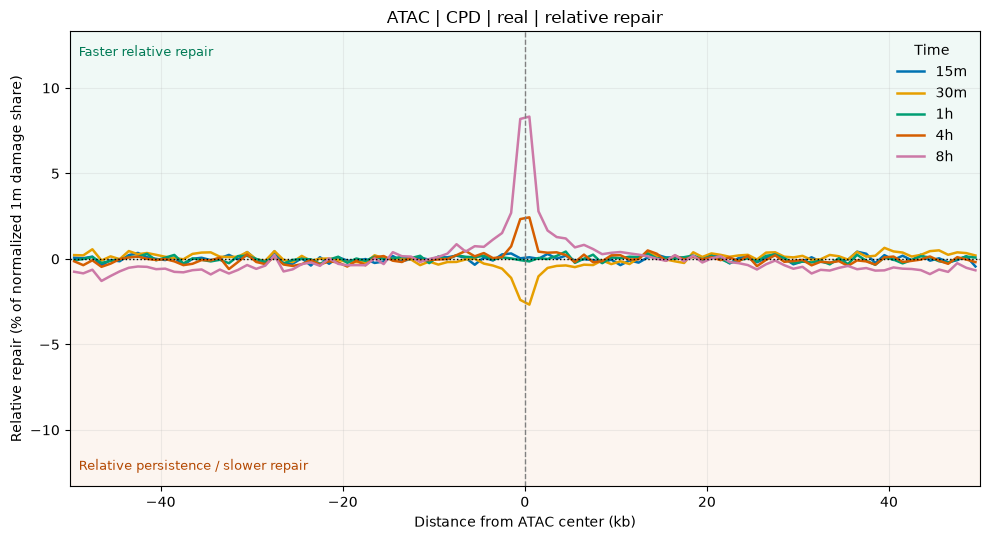

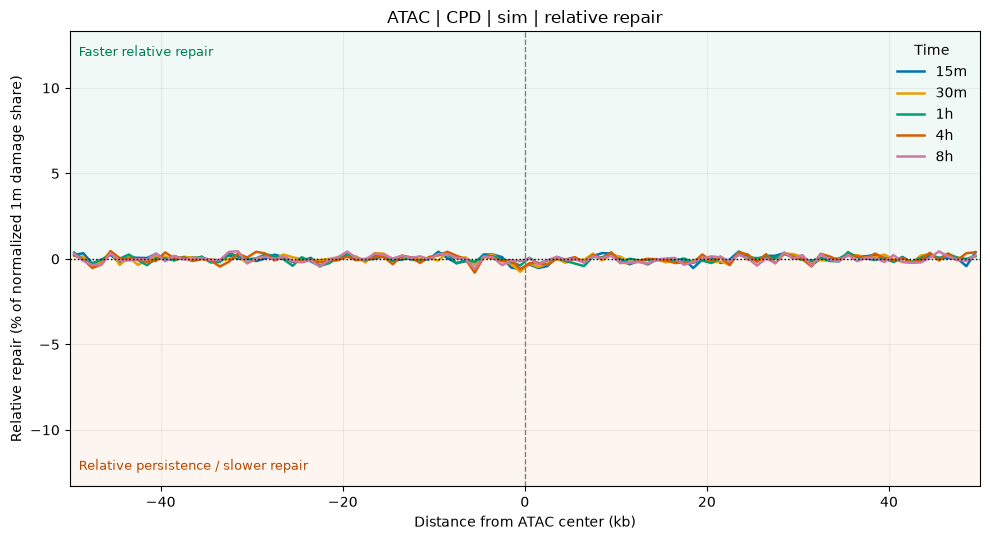

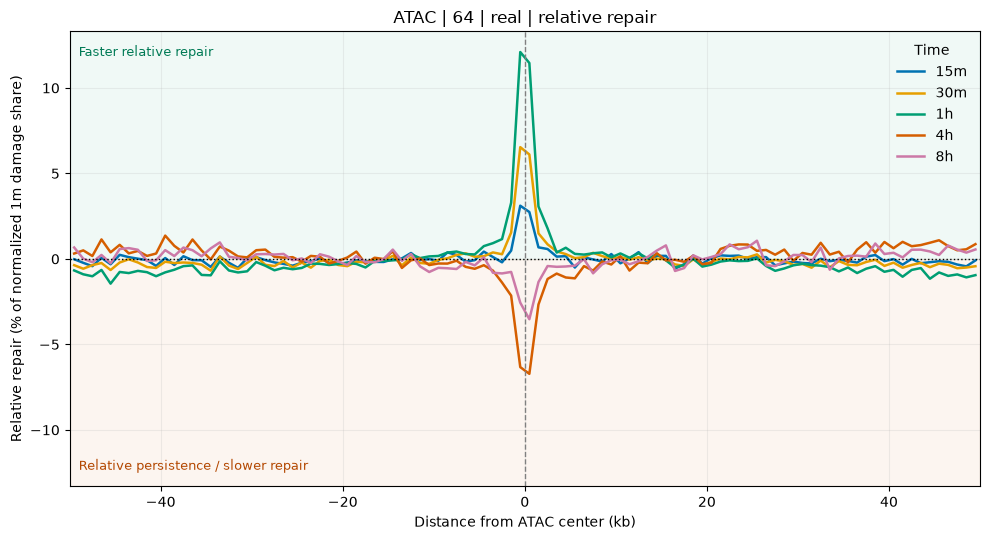

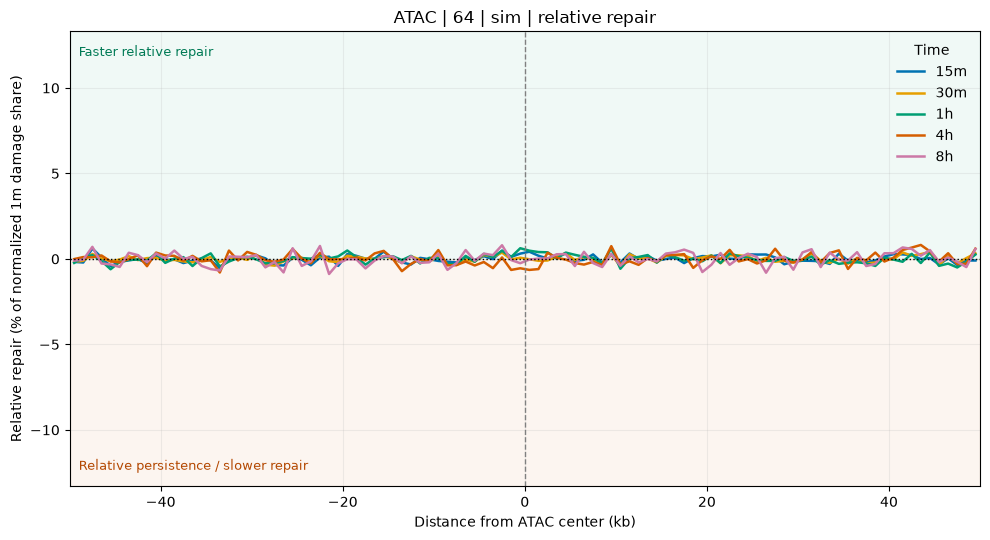

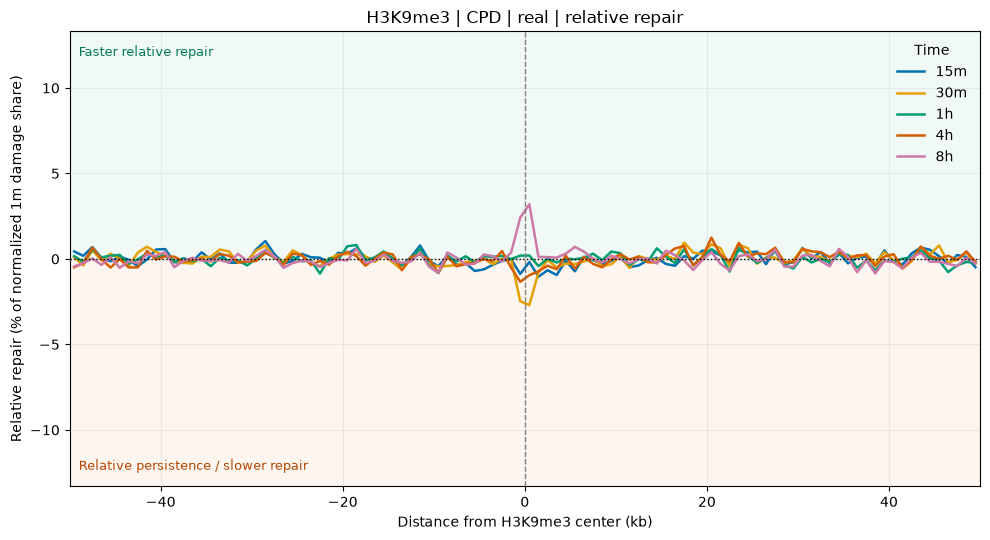

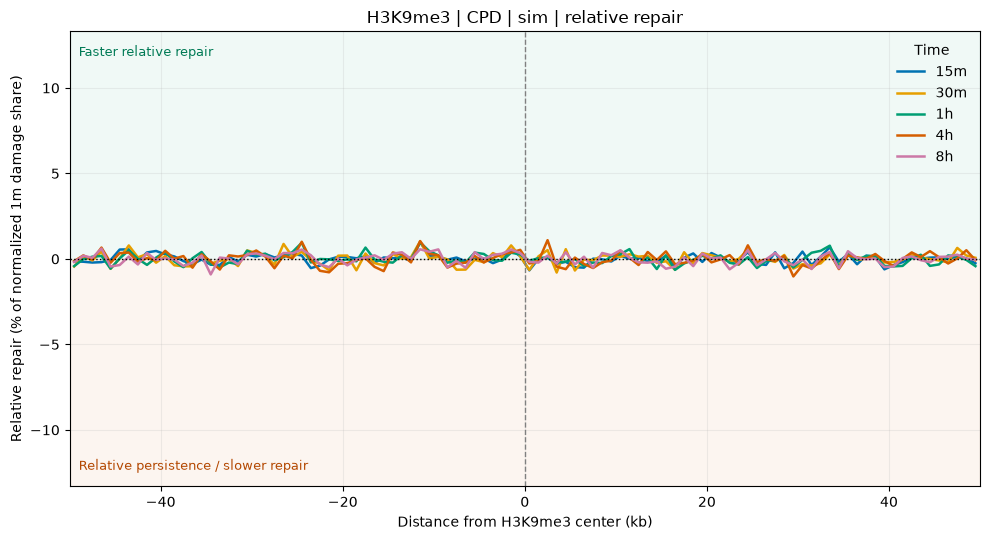

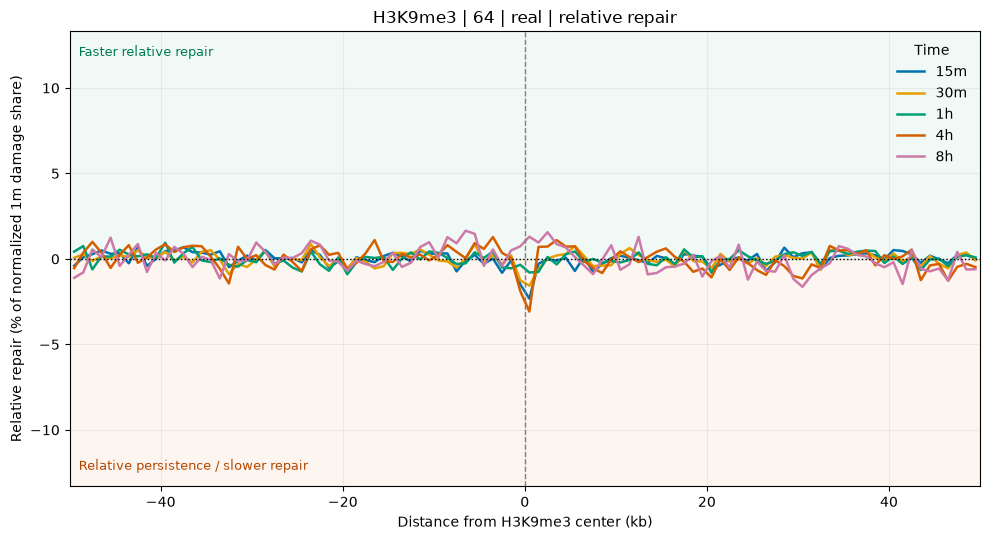

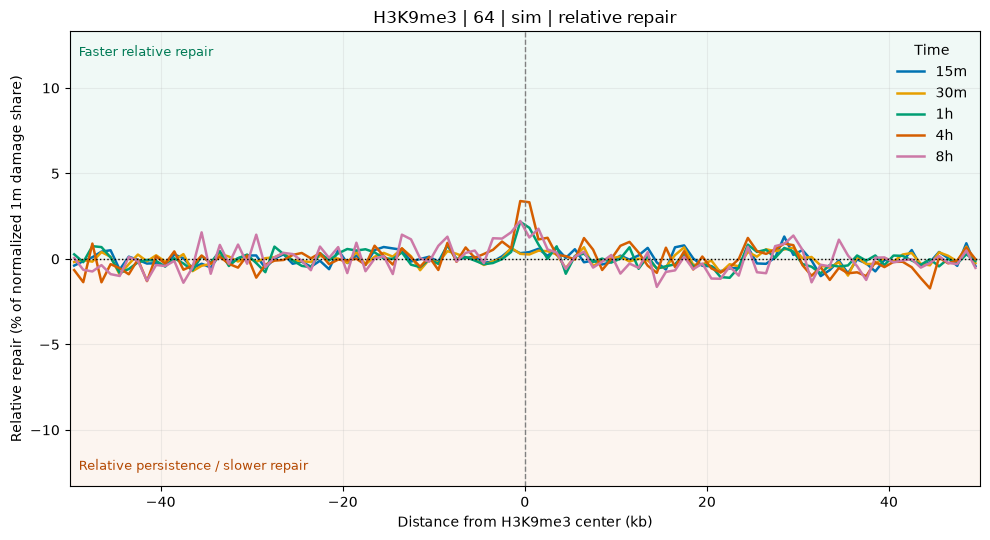

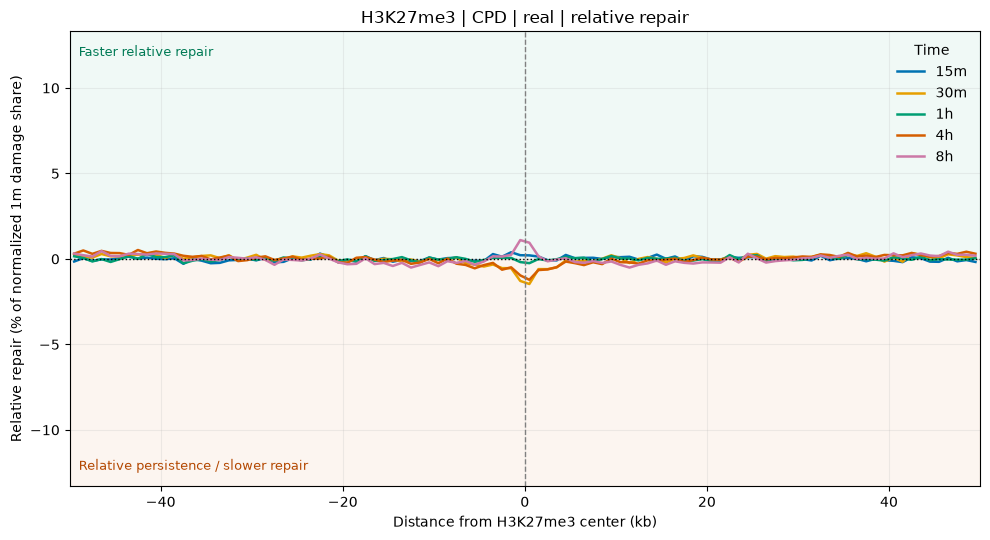

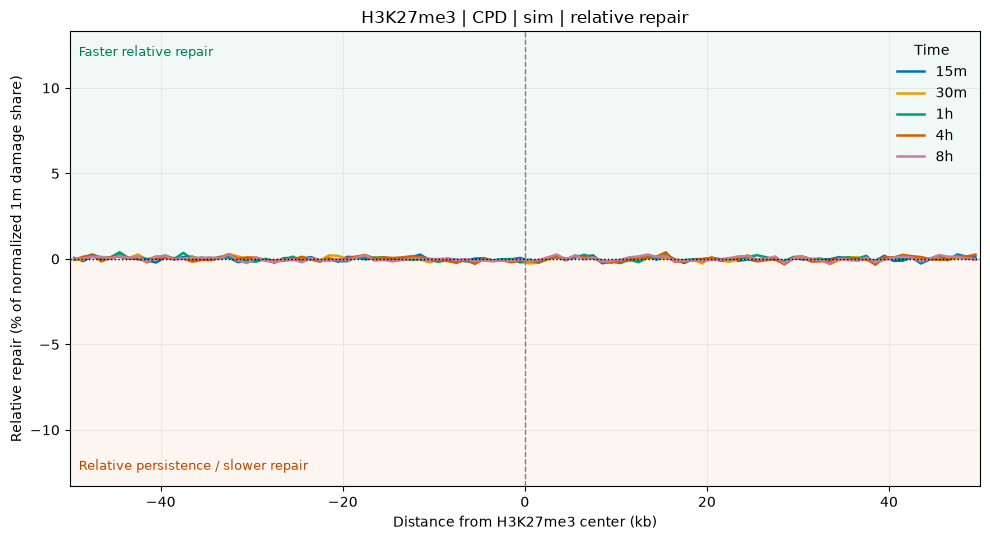

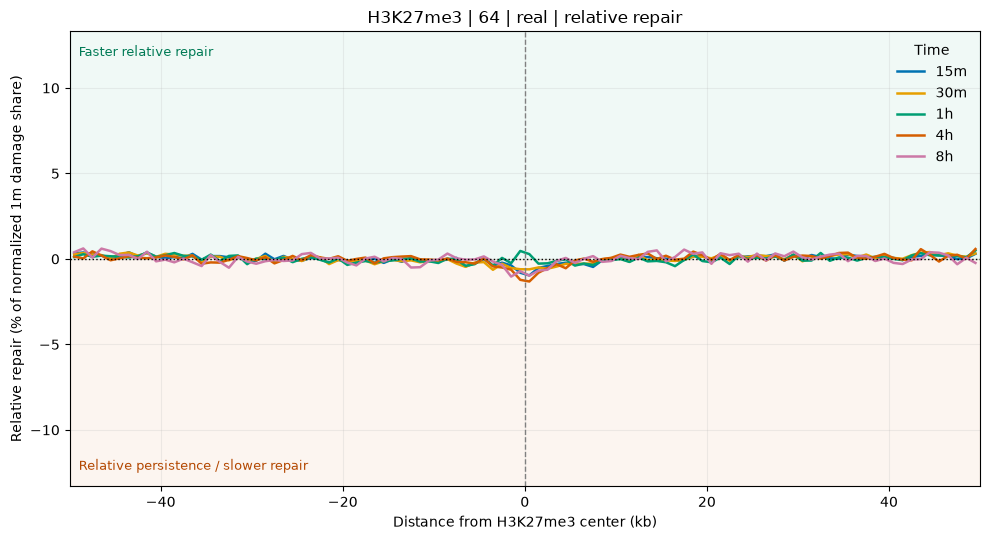

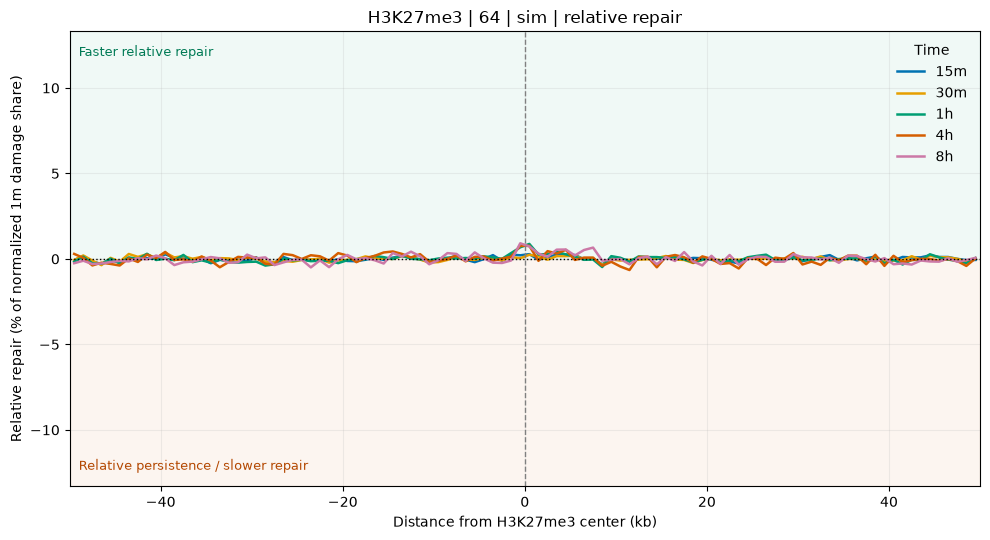

Relative-repair table and plots written to: /cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs/relative_repair_distribution_method


In [14]:
# Relative spatial repair from within-profile-normalized damage distributions.
repair_baseline = (
    damage_profiles[damage_profiles['time'] == '1m'][
        ['region', 'damage', 'kind', 'window', 'damage_percent']
    ]
    .rename(columns={'damage_percent': 'damage_percent_1m'})
)

relative_repair = damage_profiles.merge(
    repair_baseline,
    on=['region', 'damage', 'kind', 'window'],
    validate='many_to_one',
)
if (relative_repair['damage_percent_1m'] <= 0).any():
    raise ValueError('At least one normalized 1m window is zero; percent repair is undefined.')

relative_repair['relative_repair_percent'] = 100 * (
    relative_repair['damage_percent_1m']
    - relative_repair['damage_percent']
) / relative_repair['damage_percent_1m']

# Optional spatial correction: center each curve on its outer-window mean.
relative_repair['is_flank'] = relative_repair['distance_kb'].abs() >= 12.5
flank_means = (
    relative_repair[relative_repair['is_flank']]
    .groupby(['region', 'damage', 'kind', 'time'], as_index=False)[
        'relative_repair_percent'
    ].mean()
    .rename(columns={'relative_repair_percent': 'mean_flank_repair_percent'})
)
relative_repair = relative_repair.merge(
    flank_means,
    on=['region', 'damage', 'kind', 'time'],
    validate='many_to_one',
)
relative_repair['flank_referenced_repair_pp'] = (
    relative_repair['relative_repair_percent']
    - relative_repair['mean_flank_repair_percent']
)

repair_output = output_dir / 'relative_repair_distribution_method'
repair_plot_dir = repair_output / 'plots'
repair_plot_dir.mkdir(parents=True, exist_ok=True)
relative_repair.to_csv(
    repair_output / 'relative_repair_100kb_1kbwindows.tsv',
    sep='\t', index=False,
)

repair_times = [time for time in times if time != '1m']
repair_summary = (
    relative_repair[relative_repair['time'].isin(repair_times)]
    .groupby(['region', 'damage', 'kind', 'time'])['relative_repair_percent']
    .agg(window_count='size', minimum='min', maximum='max', mean='mean')
    .reset_index()
)
display(repair_summary)

# One shared symmetric limit across all regions and both damage types.
repair_values = relative_repair.loc[
    relative_repair['time'].isin(repair_times), 'relative_repair_percent'
].replace([np.inf, -np.inf], np.nan).dropna()
repair_common_limit = max(0.001, repair_values.abs().max() * 1.10)

for region in regions:
    for damage in damages:
        pair = relative_repair[
            (relative_repair['region'] == region)
            & (relative_repair['damage'] == damage)
            & (relative_repair['time'].isin(repair_times))
        ]
        common_limit = repair_common_limit
        for kind in kinds:
            selected = pair[pair['kind'] == kind]
            fig, ax = plt.subplots(figsize=(10, 5.5))
            ax.axhspan(0, common_limit, color='#009E73', alpha=0.06)
            ax.axhspan(-common_limit, 0, color='#D55E00', alpha=0.06)
            for time in repair_times:
                data = selected[selected['time'] == time].sort_values('window')
                ax.plot(
                    data['distance_kb'], data['relative_repair_percent'],
                    color=colors[time], label=time, linewidth=1.8,
                )
                values = data['relative_repair_percent'].to_numpy()
                ax.fill_between(
                    data['distance_kb'], 0, values, where=values > 0,
                    color='#56B4E9', alpha=0.10,
                )
                ax.fill_between(
                    data['distance_kb'], 0, values, where=values < 0,
                    color='#D55E00', alpha=0.10,
                )
            ax.axhline(0, color='black', linestyle=':', linewidth=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlim(-50, 50)
            ax.set_ylim(-common_limit, common_limit)
            ax.set_xlabel(f'Distance from {region} center (kb)')
            ax.set_ylabel('Relative repair (% of normalized 1m damage share)')
            ax.set_title(f'{region} | {damage} | {kind} | relative repair')
            ax.text(
                0.01, 0.97, 'Faster relative repair', transform=ax.transAxes,
                ha='left', va='top', color='#007A55', fontsize=9,
            )
            ax.text(
                0.01, 0.03, 'Relative persistence / slower repair', transform=ax.transAxes,
                ha='left', va='bottom', color='#B34700', fontsize=9,
            )
            ax.legend(title='Time', frameon=False)
            ax.grid(alpha=0.2)
            fig.tight_layout()
            fig.savefig(
                repair_plot_dir / f'{region}_{damage}_{kind}_relative_repair.png',
                dpi=300, bbox_inches='tight',
            )
            plt.show()
            plt.close(fig)

print(f'Relative-repair table and plots written to: {repair_output}')


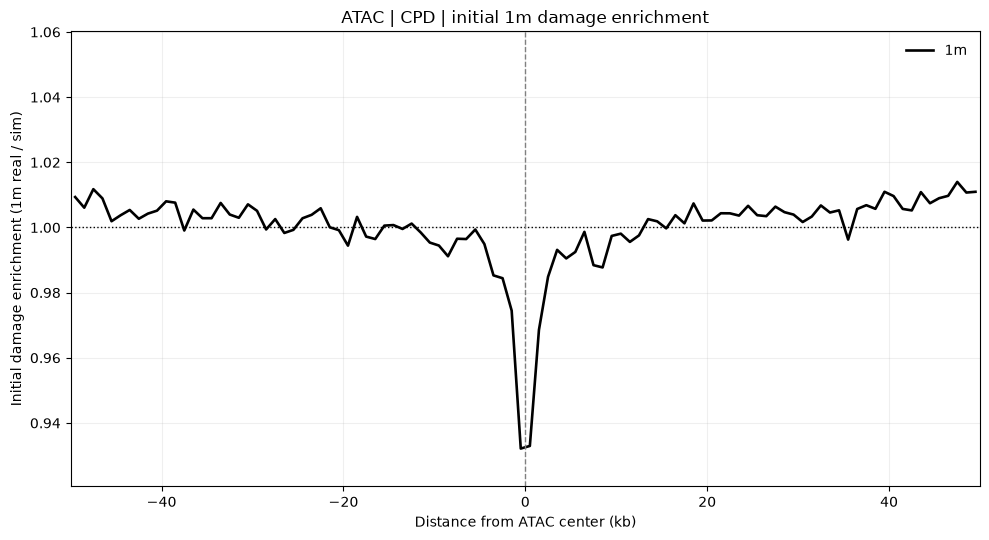

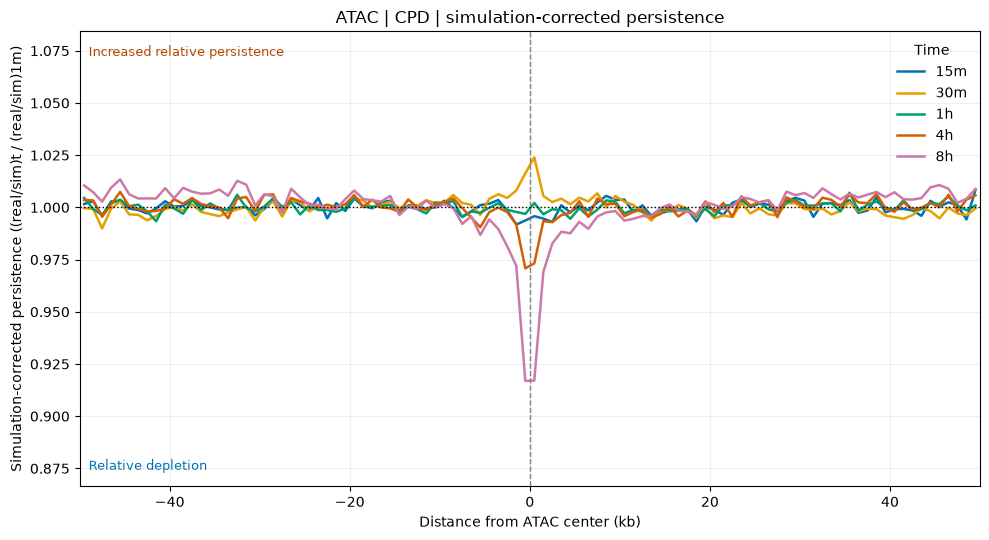

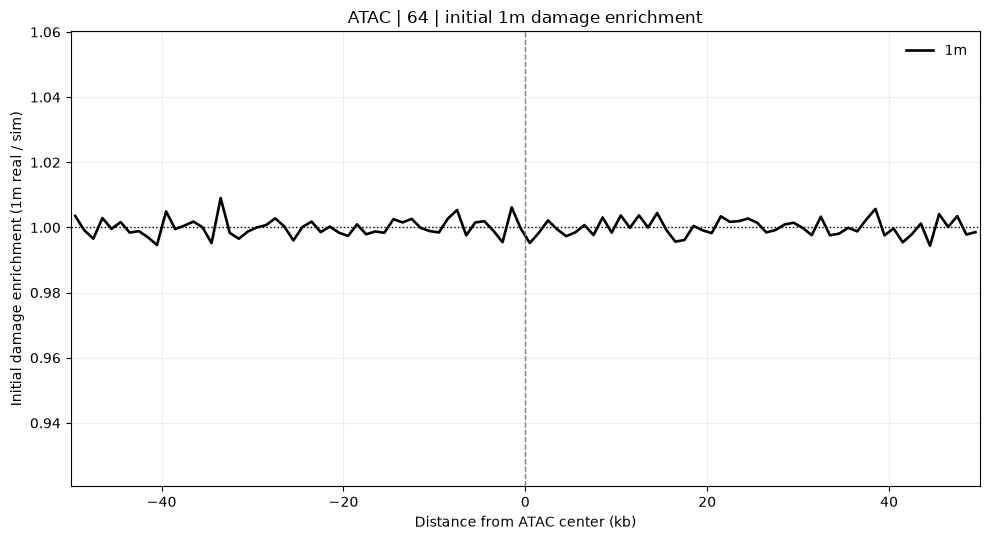

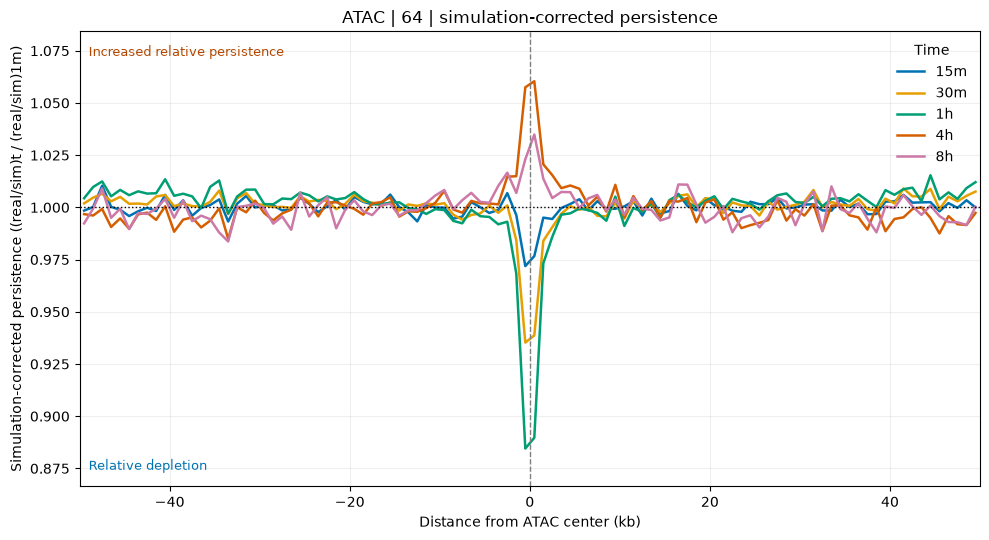

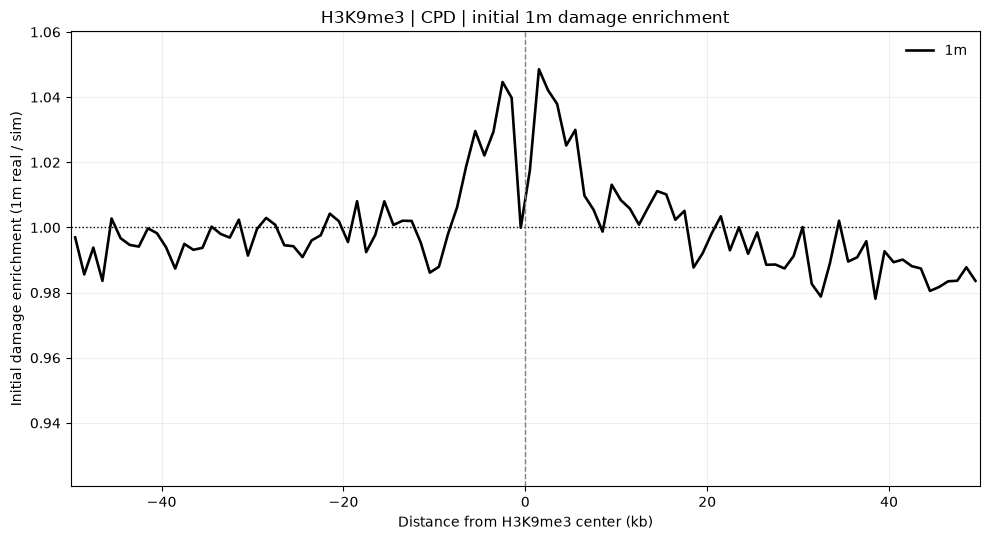

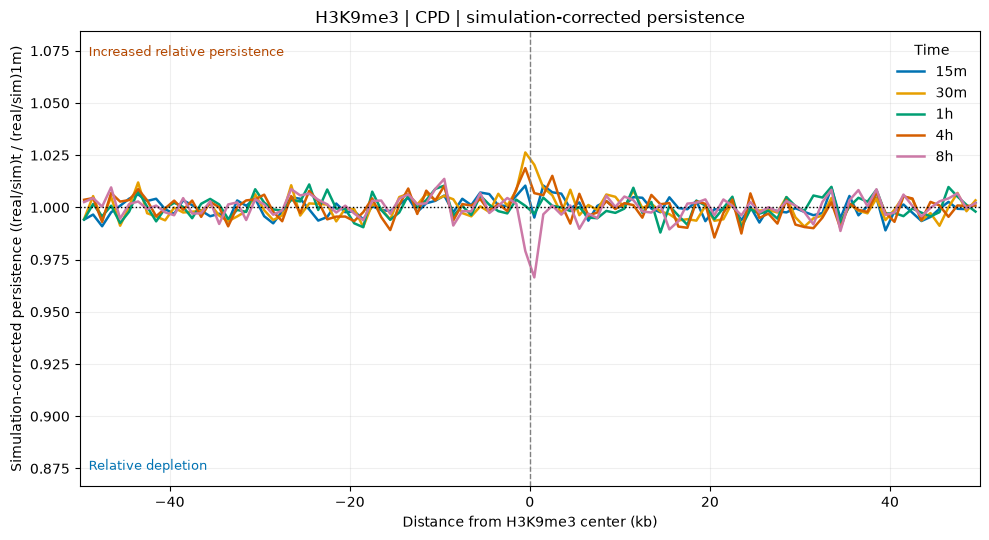

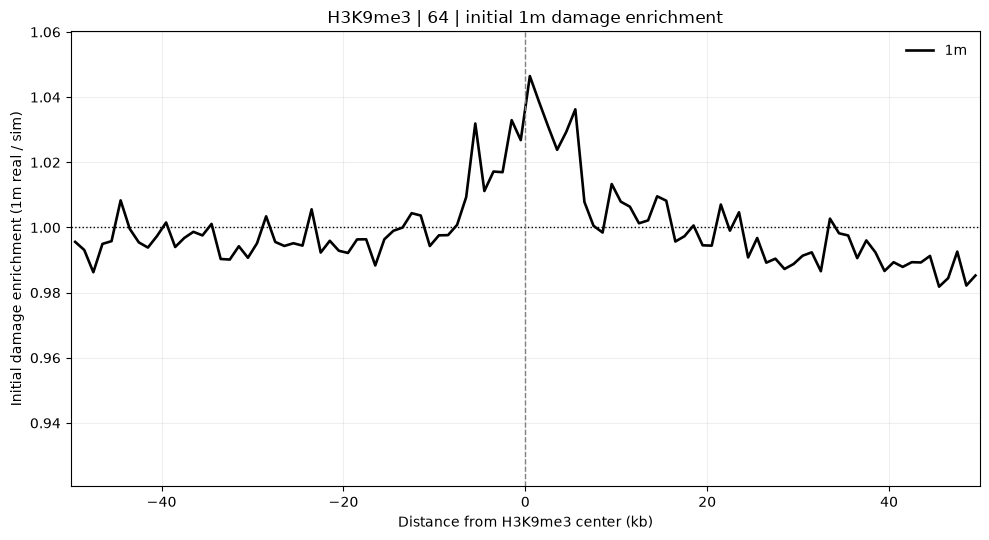

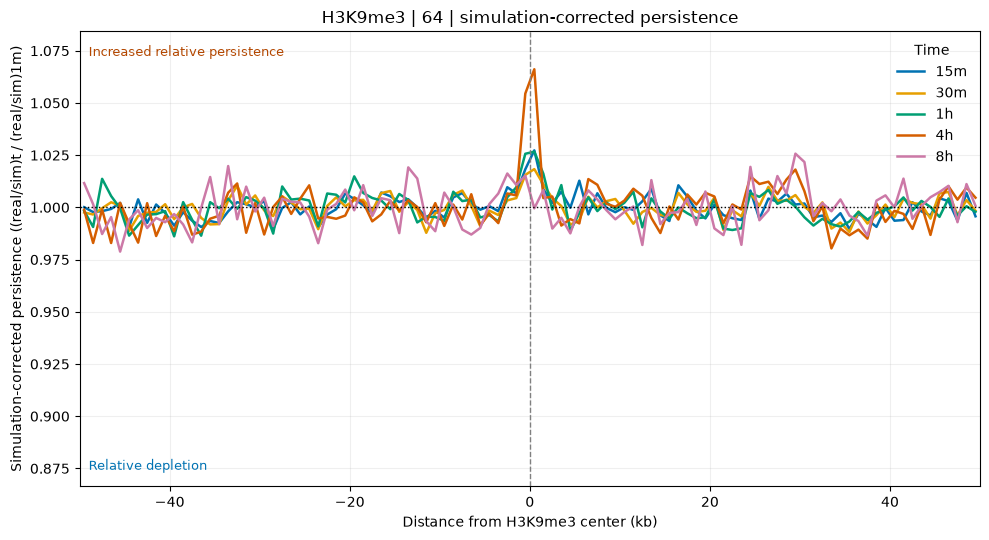

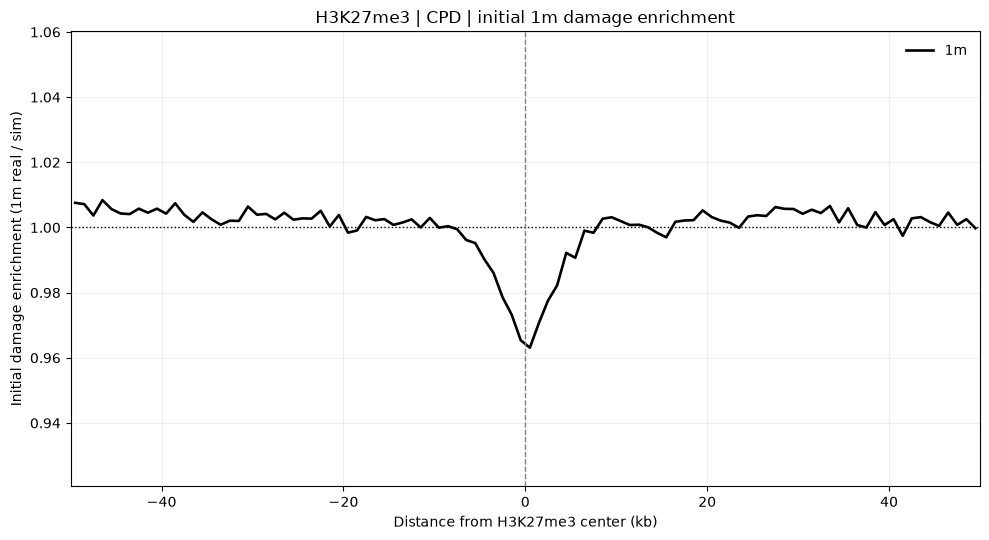

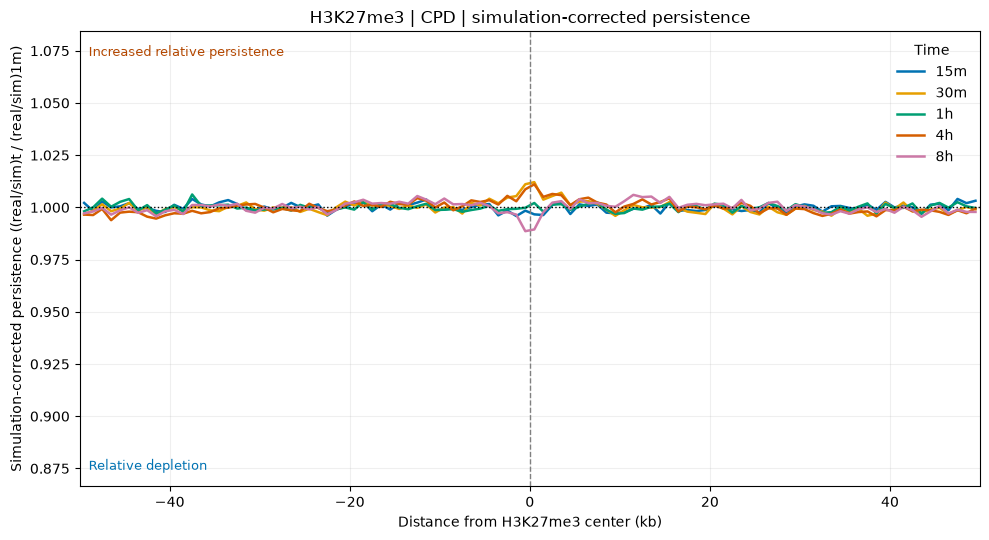

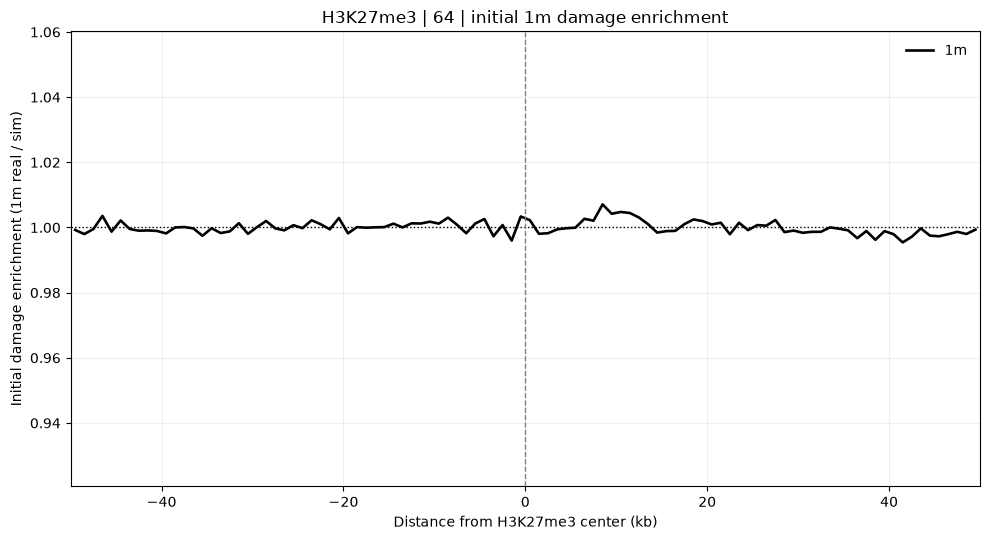

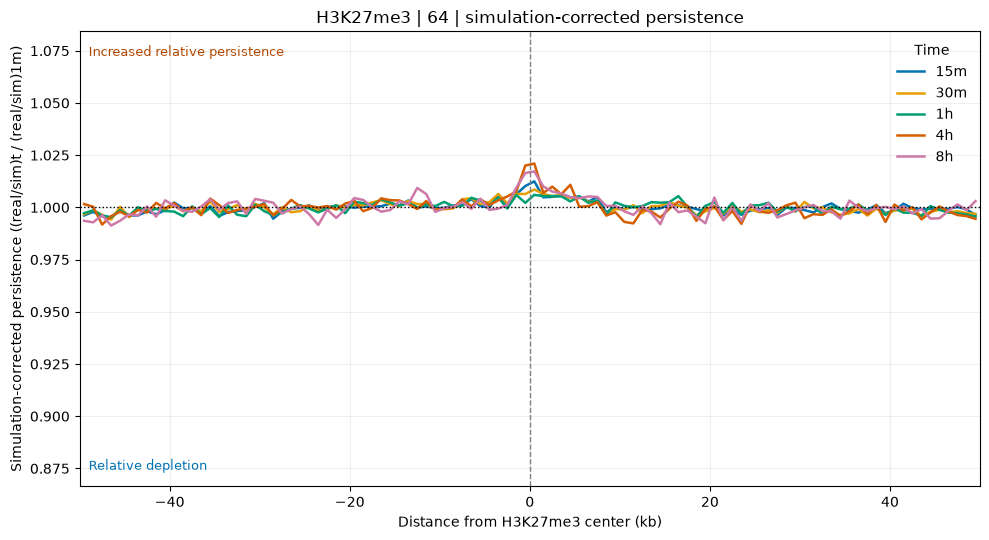

Initial enrichment plots: /cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs/real_sim_separated_interpretation/initial_1m_enrichment_plots
Simulation-corrected persistence plots: /cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs/real_sim_separated_interpretation/sim_corrected_persistence_plots


In [15]:
# Sequence/background-corrected spatial damage: normalized real distribution / normalized sim distribution.
comparison_times = [time for time in times if time != '1m']
real_distribution = (
    damage_profiles[damage_profiles['kind'] == 'real'][
        ['region', 'damage', 'time', 'window', 'distance_kb', 'damage_percent']
    ]
    .rename(columns={'damage_percent': 'real_damage_percent'})
)
sim_distribution = (
    damage_profiles[damage_profiles['kind'] == 'sim'][
        ['region', 'damage', 'time', 'window', 'damage_percent']
    ]
    .rename(columns={'damage_percent': 'sim_damage_percent'})
)
real_sim_damage = real_distribution.merge(
    sim_distribution,
    on=['region', 'damage', 'time', 'window'],
    validate='one_to_one',
)
if (real_sim_damage['sim_damage_percent'] <= 0).any():
    raise ValueError('At least one simulated window is zero; real/sim ratio is undefined.')
real_sim_damage['real_sim_ratio'] = (
    real_sim_damage['real_damage_percent']
    / real_sim_damage['sim_damage_percent']
)

initial_enrichment = real_sim_damage[real_sim_damage['time'] == '1m'].copy()
enrichment_1m = initial_enrichment[
    ['region', 'damage', 'window', 'real_sim_ratio']
].rename(columns={'real_sim_ratio': 'real_sim_ratio_1m'})
sim_corrected_persistence = real_sim_damage.merge(
    enrichment_1m,
    on=['region', 'damage', 'window'],
    validate='many_to_one',
)
if (sim_corrected_persistence['real_sim_ratio_1m'] <= 0).any():
    raise ValueError('At least one 1m real/sim value is zero; persistence is undefined.')
sim_corrected_persistence['sim_corrected_persistence_ratio'] = (
    sim_corrected_persistence['real_sim_ratio']
    / sim_corrected_persistence['real_sim_ratio_1m']
)

real_sim_output = output_dir / 'real_sim_separated_interpretation'
initial_plot_dir = real_sim_output / 'initial_1m_enrichment_plots'
persistence_plot_dir = real_sim_output / 'sim_corrected_persistence_plots'
initial_plot_dir.mkdir(parents=True, exist_ok=True)
persistence_plot_dir.mkdir(parents=True, exist_ok=True)
initial_enrichment.to_csv(
    real_sim_output / 'initial_1m_real_sim_enrichment.tsv', sep='\t', index=False,
)
sim_corrected_persistence.to_csv(
    real_sim_output / 'simulation_corrected_persistence.tsv', sep='\t', index=False,
)

# Shared limits across ATAC/H3K9me3/H3K27me3 and CPD/6-4PP.
initial_values = initial_enrichment['real_sim_ratio']
initial_low, initial_high = initial_values.min(), initial_values.max()
initial_pad = max(0.01, (initial_high - initial_low) * 0.10)
initial_ylim = (
    max(0, min(1.0, initial_low) - initial_pad),
    max(1.0, initial_high) + initial_pad,
)
corrected_values = sim_corrected_persistence.loc[
    sim_corrected_persistence['time'] != '1m', 'sim_corrected_persistence_ratio'
]
corrected_low, corrected_high = corrected_values.min(), corrected_values.max()
corrected_pad = max(0.01, (corrected_high - corrected_low) * 0.10)
corrected_persistence_ylim = (
    max(0, min(1.0, corrected_low) - corrected_pad),
    max(1.0, corrected_high) + corrected_pad,
)

for region in regions:
    for damage in damages:
        initial = initial_enrichment[
            (initial_enrichment['region'] == region)
            & (initial_enrichment['damage'] == damage)
        ].sort_values('window')
        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.plot(
            initial['distance_kb'], initial['real_sim_ratio'],
            color=colors['1m'], linewidth=1.9, label='1m',
        )
        ax.axhline(1, color='black', linestyle=':', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlim(-50, 50)
        ax.set_ylim(*initial_ylim)
        ax.set_xlabel(f'Distance from {region} center (kb)')
        ax.set_ylabel('Initial damage enrichment (1m real / sim)')
        ax.set_title(f'{region} | {damage} | initial 1m damage enrichment')
        ax.legend(frameon=False)
        ax.grid(alpha=0.2)
        fig.tight_layout()
        fig.savefig(
            initial_plot_dir / f'{region}_{damage}_initial_1m_enrichment.png',
            dpi=300, bbox_inches='tight',
        )
        plt.show()
        plt.close(fig)

        persistence = sim_corrected_persistence[
            (sim_corrected_persistence['region'] == region)
            & (sim_corrected_persistence['damage'] == damage)
            & (sim_corrected_persistence['time'] != '1m')
        ]
        fig, ax = plt.subplots(figsize=(10, 5.5))
        for time in comparison_times:
            data = persistence[persistence['time'] == time].sort_values('window')
            ax.plot(
                data['distance_kb'], data['sim_corrected_persistence_ratio'],
                color=colors[time], label=time, linewidth=1.8,
            )
            values = data['sim_corrected_persistence_ratio'].to_numpy()
            ax.fill_between(
                data['distance_kb'], 1, values, where=values < 1,
                color='#56B4E9', alpha=0.10,
            )
            ax.fill_between(
                data['distance_kb'], 1, values, where=values > 1,
                color='#D55E00', alpha=0.10,
            )
        ax.axhline(1, color='black', linestyle=':', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlim(-50, 50)
        ax.set_ylim(*corrected_persistence_ylim)
        ax.set_xlabel(f'Distance from {region} center (kb)')
        ax.set_ylabel('Simulation-corrected persistence ((real/sim)t / (real/sim)1m)')
        ax.set_title(f'{region} | {damage} | simulation-corrected persistence')
        ax.text(
            0.01, 0.97, 'Increased relative persistence', transform=ax.transAxes,
            ha='left', va='top', color='#B34700', fontsize=9,
        )
        ax.text(
            0.01, 0.03, 'Relative depletion', transform=ax.transAxes,
            ha='left', va='bottom', color='#0072B2', fontsize=9,
        )
        ax.legend(title='Time', frameon=False)
        ax.grid(alpha=0.2)
        fig.tight_layout()
        fig.savefig(
            persistence_plot_dir / f'{region}_{damage}_sim_corrected_persistence.png',
            dpi=300, bbox_inches='tight',
        )
        plt.show()
        plt.close(fig)

print(f'Initial enrichment plots: {initial_plot_dir}')
print(f'Simulation-corrected persistence plots: {persistence_plot_dir}')


,damage,time,damage_bed,global_damage_records,global_damage_records_1m,remaining_vs_1m_percent,naive_global_repair_percent
0,CPD,1m,/cta/users/guneyn23/damageseq_data/R3Hela_1mCP...,32539066,32539066,100.000000,0.000000
1,CPD,15m,/cta/users/guneyn23/damageseq_data/R3Hela_15mC...,31909633,32539066,98.065608,1.934392
2,CPD,30m,/cta/users/guneyn23/damageseq_data/R3Hela_30mC...,33454037,32539066,102.811915,-2.811915
3,CPD,1h,/cta/users/guneyn23/damageseq_data/R3Hela_1hCP...,34070806,32539066,104.707388,-4.707388
4,CPD,4h,/cta/users/guneyn23/damageseq_data/R3Hela_4hCP...,33084318,32539066,101.675684,-1.675684
5,CPD,8h,/cta/users/guneyn23/damageseq_data/R3Hela_8hCP...,37456000,32539066,115.110864,-15.110864
6,64,1m,/cta/users/guneyn23/damageseq_data/R3Hela_1m64...,24841279,24841279,100.000000,0.000000
7,64,15m,/cta/users/guneyn23/damageseq_data/R3Hela_15m6...,32381905,24841279,130.355224,-30.355224
8,64,30m,/cta/users/guneyn23/damageseq_data/R3Hela_30m6...,48060015,24841279,193.468360,-93.468360
9,64,1h,/cta/users/guneyn23/damageseq_data/R3Hela_1h64...,24790234,24841279,99.794515,0.205485


,region,damage,time,profile_total_count,overlap_total_1m,overlap_remaining_vs_1m_percent,naive_overlap_repair_percent,global_damage_records,remaining_vs_1m_percent,naive_global_repair_percent
0,ATAC,CPD,1m,53685618,53685618,100.000000,0.000000,32539066,100.000000,0.000000
1,ATAC,CPD,15m,52591924,53685618,97.962780,2.037220,31909633,98.065608,1.934392
2,ATAC,CPD,30m,56471928,53685618,105.190049,-5.190049,33454037,102.811915,-2.811915
3,ATAC,CPD,1h,55519697,53685618,103.416332,-3.416332,34070806,104.707388,-4.707388
4,ATAC,CPD,4h,54297456,53685618,101.139668,-1.139668,33084318,101.675684,-1.675684
5,ATAC,CPD,8h,57694118,53685618,107.466618,-7.466618,37456000,115.110864,-15.110864
6,ATAC,64,1m,45063087,45063087,100.000000,0.000000,24841279,100.000000,0.000000
7,ATAC,64,15m,57659343,45063087,127.952492,-27.952492,32381905,130.355224,-30.355224
8,ATAC,64,30m,83363126,45063087,184.992045,-84.992045,48060015,193.468360,-93.468360
9,ATAC,64,1h,40059161,45063087,88.895732,11.104268,24790234,99.794515,0.205485


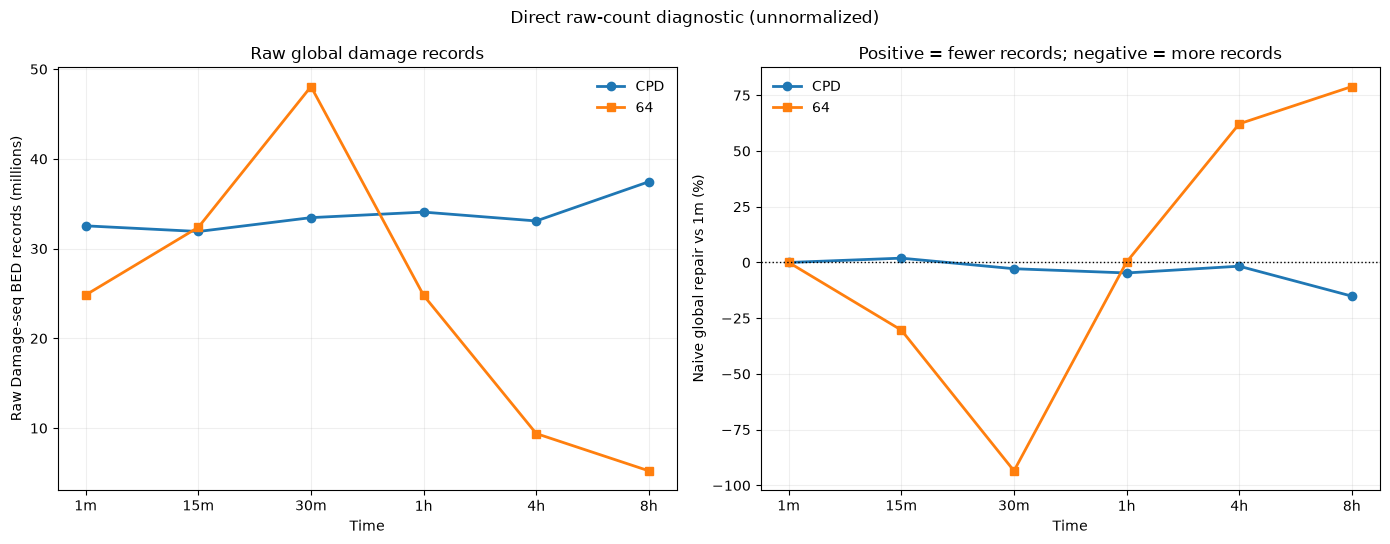

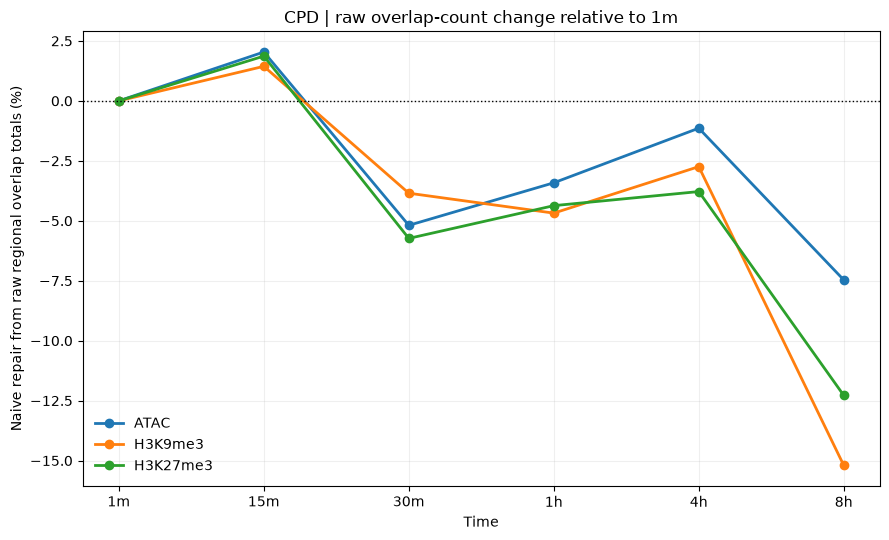

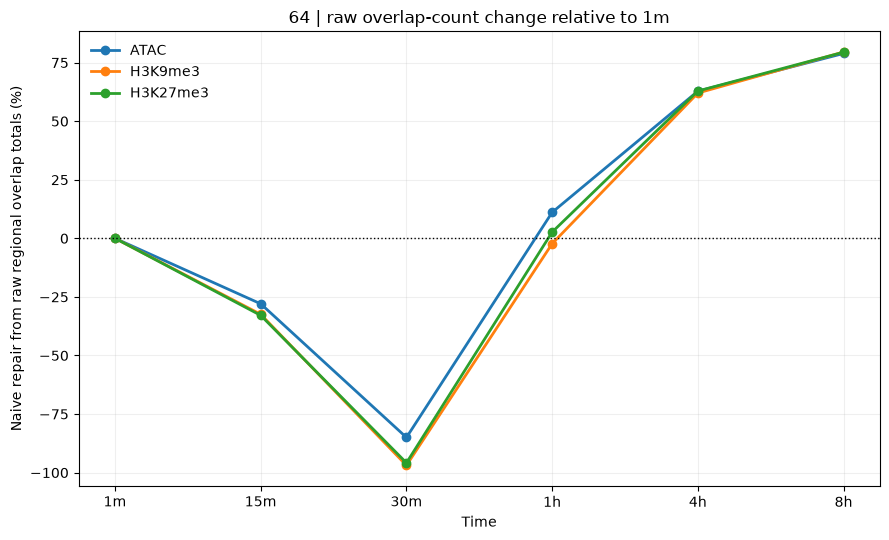

Raw global-count tables and plots written to: /cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs/raw_global_count_diagnostic


In [16]:
# Direct global-count view from real Damage-seq BED records (no additional scaling).
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

times = ['1m', '15m', '30m', '1h', '4h', '8h']
regions = ['ATAC', 'H3K9me3', 'H3K27me3']
damages = ['CPD', '64']
output_dir = Path('/cta/users/guneyn23/damage_profile_trial_100kb_1kbwindows/outputs')
damage_profile_table = output_dir / 'damage_profiles_100kb_1kbwindows.tsv'
if 'damage_profiles' not in globals():
    if not damage_profile_table.is_file():
        raise FileNotFoundError(
            f'Run the main count cell first; missing: {damage_profile_table}'
        )
    damage_profiles = pd.read_csv(damage_profile_table, sep='\t')

damage_bed_dir = Path('/cta/users/guneyn23/damageseq_data')

def unique_damage_bed(time, damage):
    matches = sorted(damage_bed_dir.glob(f'R3Hela_{time}{damage}_*_DS.bed'))
    if len(matches) != 1:
        raise RuntimeError(f'Expected one BED for {time} {damage}, found: {matches}')
    return matches[0]

def count_bed_records(path):
    completed = subprocess.run(
        ['wc', '-l', str(path)], check=True, capture_output=True, text=True,
    )
    return int(completed.stdout.split()[0])

global_rows = []
for damage in damages:
    for time in times:
        path = unique_damage_bed(time, damage)
        global_rows.append({
            'damage': damage, 'time': time,
            'damage_bed': str(path),
            'global_damage_records': count_bed_records(path),
        })
raw_global = pd.DataFrame(global_rows)
global_1m = raw_global[raw_global['time'] == '1m'][
    ['damage', 'global_damage_records']
].rename(columns={'global_damage_records': 'global_damage_records_1m'})
raw_global = raw_global.merge(global_1m, on='damage', validate='many_to_one')
raw_global['remaining_vs_1m_percent'] = 100 * (
    raw_global['global_damage_records'] / raw_global['global_damage_records_1m']
)
raw_global['naive_global_repair_percent'] = (
    100 - raw_global['remaining_vs_1m_percent']
)

raw_overlap = (
    damage_profiles[damage_profiles['kind'] == 'real'][
        ['region', 'damage', 'time', 'profile_total_count']
    ]
    .drop_duplicates(['region', 'damage', 'time'])
)
overlap_1m = raw_overlap[raw_overlap['time'] == '1m'][
    ['region', 'damage', 'profile_total_count']
].rename(columns={'profile_total_count': 'overlap_total_1m'})
raw_overlap = raw_overlap.merge(
    overlap_1m, on=['region', 'damage'], validate='many_to_one',
)
raw_overlap['overlap_remaining_vs_1m_percent'] = 100 * (
    raw_overlap['profile_total_count'] / raw_overlap['overlap_total_1m']
)
raw_overlap['naive_overlap_repair_percent'] = (
    100 - raw_overlap['overlap_remaining_vs_1m_percent']
)
raw_overlap = raw_overlap.merge(
    raw_global[[
        'damage', 'time', 'global_damage_records',
        'remaining_vs_1m_percent', 'naive_global_repair_percent',
    ]],
    on=['damage', 'time'], validate='many_to_one',
)

raw_global_output = output_dir / 'raw_global_count_diagnostic'
raw_global_plot_dir = raw_global_output / 'plots'
raw_global_plot_dir.mkdir(parents=True, exist_ok=True)
raw_global.to_csv(raw_global_output / 'raw_global_damage_counts.tsv', sep='\t', index=False)
raw_overlap.to_csv(raw_global_output / 'raw_region_overlap_counts.tsv', sep='\t', index=False)
display(raw_global)
display(raw_overlap)

time_positions = np.arange(len(times))
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for damage, marker in [('CPD', 'o'), ('64', 's')]:
    data = raw_global[raw_global['damage'] == damage].set_index('time').loc[times]
    axes[0].plot(
        time_positions, data['global_damage_records'] / 1_000_000,
        marker=marker, linewidth=2, label=damage,
    )
    axes[1].plot(
        time_positions, data['naive_global_repair_percent'],
        marker=marker, linewidth=2, label=damage,
    )
axes[0].set_ylabel('Raw Damage-seq BED records (millions)')
axes[0].set_title('Raw global damage records')
axes[1].axhline(0, color='black', linestyle=':', linewidth=1)
axes[1].set_ylabel('Naive global repair vs 1m (%)')
axes[1].set_title('Positive = fewer records; negative = more records')
for ax in axes:
    ax.set_xticks(time_positions, times)
    ax.set_xlabel('Time')
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
fig.suptitle('Direct raw-count diagnostic (unnormalized)')
fig.tight_layout()
fig.savefig(
    raw_global_plot_dir / 'raw_global_damage_and_naive_repair.png',
    dpi=300, bbox_inches='tight',
)
plt.show()
plt.close(fig)

for damage in damages:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for region in regions:
        data = raw_overlap[
            (raw_overlap['damage'] == damage)
            & (raw_overlap['region'] == region)
        ].set_index('time').loc[times]
        ax.plot(
            time_positions, data['naive_overlap_repair_percent'],
            marker='o', linewidth=2, label=region,
        )
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    ax.set_xticks(time_positions, times)
    ax.set_xlabel('Time')
    ax.set_ylabel('Naive repair from raw regional overlap totals (%)')
    ax.set_title(f'{damage} | raw overlap-count change relative to 1m')
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(
        raw_global_plot_dir / f'{damage}_raw_region_overlap_naive_repair.png',
        dpi=300, bbox_inches='tight',
    )
    plt.show()
    plt.close(fig)

print(f'Raw global-count tables and plots written to: {raw_global_output}')
